In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class LearnedSparseLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True, hard_threshold:float=0.5):
        super().__init__()
        self.in_features = int(in_features)
        self.out_features = int(out_features)

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)

        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None

        self.logits = nn.Parameter(torch.zeros(out_features, in_features).normal_(mean=0.0, std=0.1))

        self.temperature = 1.0
        self.hard_threshold = hard_threshold

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim != 2 or x.shape[1] != self.in_features:
            raise ValueError(f"x debe ser (B, {self.in_features})")

        gate_soft = torch.sigmoid(self.logits / self.temperature)
        gate_hard = (gate_soft > self.hard_threshold).to(x.dtype)

        gate = gate_hard - gate_soft.detach() + gate_soft

        w_eff = self.weight * gate
        return F.linear(x, w_eff, self.bias)

    @torch.no_grad()
    def gate_soft(self) -> torch.Tensor:
        return torch.sigmoid(self.logits / self.temperature)

    def sparsity_loss(self) -> torch.Tensor:
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        return gate_soft.mean()

    @torch.no_grad()
    def hard_mask(self) -> torch.Tensor:
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        return (gate_soft > self.hard_threshold)

class VAE(nn.Module):
    def __init__(self, input_dim, output_dim, latent_dim=128):
        super(VAE, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.fc1 = LearnedSparseLinear(input_dim, 400)
        self.fc21 = LearnedSparseLinear(400, latent_dim)
        self.fc22 = LearnedSparseLinear(400, latent_dim)
        self.fc3 = LearnedSparseLinear(latent_dim, 400)
        self.fc4 = LearnedSparseLinear(400, output_dim)
        
    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, self.input_dim))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

class DeMemte(nn.Module):
    def __init__(self, backbone, vae, embedding_dim, num_classes):
        super().__init__()
        self.backbone = backbone 
        self.vae = vae           
        
        self.feat_norm = nn.LayerNorm(embedding_dim)
        self.signal_gamma = nn.Parameter(torch.ones(1) * 0.1)
        self.memory_scale = nn.Parameter(torch.ones(1))
        self.classifier = LearnedSparseLinear(embedding_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            raw_features = self.backbone(x)
        features = self.feat_norm(raw_features)
        
        x_rec, mu, logvar = self.vae(features)
        
        recon_diff = (features - x_rec)**2
        recon_loss_per_sample = torch.mean(recon_diff, dim=1, keepdim=True)
        
        gamma = F.softplus(self.signal_gamma) 
        signal = torch.exp(-recon_loss_per_sample * gamma)
        
        enhanced_features = features + (self.memory_scale * signal * x_rec)
        logits = self.classifier(enhanced_features)
        
        return logits, x_rec, mu, logvar, features

    def train(self, mode: bool = True):
        super().train(mode)
        self.backbone.eval()
        return self

def get_resnet_baseline(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_dememte_model(num_classes):
    base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone = torch.nn.Sequential(*list(base_model.children())[:-1], torch.nn.Flatten())
    for param in backbone.parameters():
        param.requires_grad = False
    embedding_dim = base_model.fc.in_features
    vae = VAE(input_dim=embedding_dim, output_dim=embedding_dim, latent_dim=128)
    model = DeMemte(backbone, vae, embedding_dim, num_classes)
    return model

In [3]:
batch_size = 64
data_dir = '../data'

# Standard Transforms
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

# Perturbed Transforms (Gaussian Noise)
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=1.):
        self.std = std
        self.mean = mean
        
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean
        
    def __repr__(self):
        return self.__class__.__name__ + '(mean={0}, std={1})'.format(self.mean, self.std)

transform_perturbed = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    AddGaussianNoise(0., 0.5) # Add noise
])

print("Loading Flowers102 datasets...")
testset_flowers = torchvision.datasets.Flowers102(root=data_dir, split='test', download=True, transform=transform_test)
testloader_flowers = torch.utils.data.DataLoader(testset_flowers, batch_size=batch_size, shuffle=False, num_workers=2)

testset_flowers_pert = torchvision.datasets.Flowers102(root=data_dir, split='test', download=True, transform=transform_perturbed)
testloader_flowers_pert = torch.utils.data.DataLoader(testset_flowers_pert, batch_size=batch_size, shuffle=False, num_workers=2)

print("Loading CIFAR-10 datasets...")
trainset_cifar = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform_test)
trainloader_cifar = torch.utils.data.DataLoader(trainset_cifar, batch_size=batch_size, shuffle=False, num_workers=2)

testset_cifar = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform_test)
testloader_cifar = torch.utils.data.DataLoader(testset_cifar, batch_size=batch_size, shuffle=False, num_workers=2)
print("Datasets loaded.")

Loading Flowers102 datasets...
Loading CIFAR-10 datasets...


/home/nakato/projects/Dmente/env/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Datasets loaded.


In [4]:
num_classes_flowers = 102

print("Loading Baseline ResNet18...")
baseline_model = get_resnet_baseline(num_classes_flowers).to(device)
baseline_ckpt = torch.load('../out/baseline_resnet18_flowers102.pth', map_location=device)
baseline_model.load_state_dict(baseline_ckpt['model_state_dict'])
baseline_model.eval()

print("Loading DeMemte...")
dememte_model = get_dememte_model(num_classes_flowers).to(device)
dememte_ckpt = torch.load('../out/dememte_optimized_flowers102.pth', map_location=device)
dememte_model.load_state_dict(dememte_ckpt['model_state_dict'])
dememte_model.eval()

print("Models loaded successfully.")

Loading Baseline ResNet18...
Loading DeMemte...
Models loaded successfully.


In [5]:
def evaluate_model(model, testloader, is_dememte=False):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            if is_dememte:
                outputs, _, _, _, _ = model(inputs)
            else:
                outputs = model(inputs)
                
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    return 100 * correct / total

def extract_features(model, dataloader, is_dememte=False, max_samples=5000):
    model.eval()
    features_list = []
    labels_list = []
    total_samples = 0
    
    if not is_dememte:
        backbone = torch.nn.Sequential(*list(model.children())[:-1], torch.nn.Flatten())
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            if is_dememte:
                _, _, _, _, feats = model(inputs)
            else:
                feats = backbone(inputs)
                
            features_list.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
            
            total_samples += inputs.size(0)
            if total_samples >= max_samples:
                break
                
    return np.vstack(features_list)[:max_samples], np.concatenate(labels_list)[:max_samples]

In [6]:
print("--- Original Flowers102 Test Set ---")
acc_base = evaluate_model(baseline_model, testloader_flowers, is_dememte=False)
acc_dememte = evaluate_model(dememte_model, testloader_flowers, is_dememte=True)
print(f"Baseline ResNet18 Accuracy: {acc_base:.2f}%")
print(f"DeMemte Accuracy: {acc_dememte:.2f}%")

print("\n--- Perturbed Flowers102 Test Set (Gaussian Noise) ---")
acc_base_pert = evaluate_model(baseline_model, testloader_flowers_pert, is_dememte=False)
acc_dememte_pert = evaluate_model(dememte_model, testloader_flowers_pert, is_dememte=True)
print(f"Baseline ResNet18 Accuracy: {acc_base_pert:.2f}%")
print(f"DeMemte Accuracy: {acc_dememte_pert:.2f}%")

--- Original Flowers102 Test Set ---
Baseline ResNet18 Accuracy: 80.78%
DeMemte Accuracy: 79.22%

--- Perturbed Flowers102 Test Set (Gaussian Noise) ---
Baseline ResNet18 Accuracy: 35.84%
DeMemte Accuracy: 34.25%


In [7]:
print("Extracting features for CIFAR-10...")
# Use a subset to speed up k-NN
X_train_base, y_train_base = extract_features(baseline_model, trainloader_cifar, is_dememte=False, max_samples=5000)
X_test_base, y_test_base = extract_features(baseline_model, testloader_cifar, is_dememte=False, max_samples=1000)

X_train_dem, y_train_dem = extract_features(dememte_model, trainloader_cifar, is_dememte=True, max_samples=5000)
X_test_dem, y_test_dem = extract_features(dememte_model, testloader_cifar, is_dememte=True, max_samples=1000)

print("Training k-NN classifiers...")
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_base, y_train_base)
acc_knn_base = accuracy_score(y_test_base, knn_base.predict(X_test_base))

knn_dem = KNeighborsClassifier(n_neighbors=5)
knn_dem.fit(X_train_dem, y_train_dem)
acc_knn_dem = accuracy_score(y_test_dem, knn_dem.predict(X_test_dem))

print(f"Baseline ResNet18 CIFAR-10 k-NN Accuracy: {acc_knn_base*100:.2f}%")
print(f"DeMemte CIFAR-10 k-NN Accuracy: {acc_knn_dem*100:.2f}%")

Extracting features for CIFAR-10...
Training k-NN classifiers...
Baseline ResNet18 CIFAR-10 k-NN Accuracy: 65.90%
DeMemte CIFAR-10 k-NN Accuracy: 77.40%


Extracting features for t-SNE (Flowers102)...
Computing t-SNE...


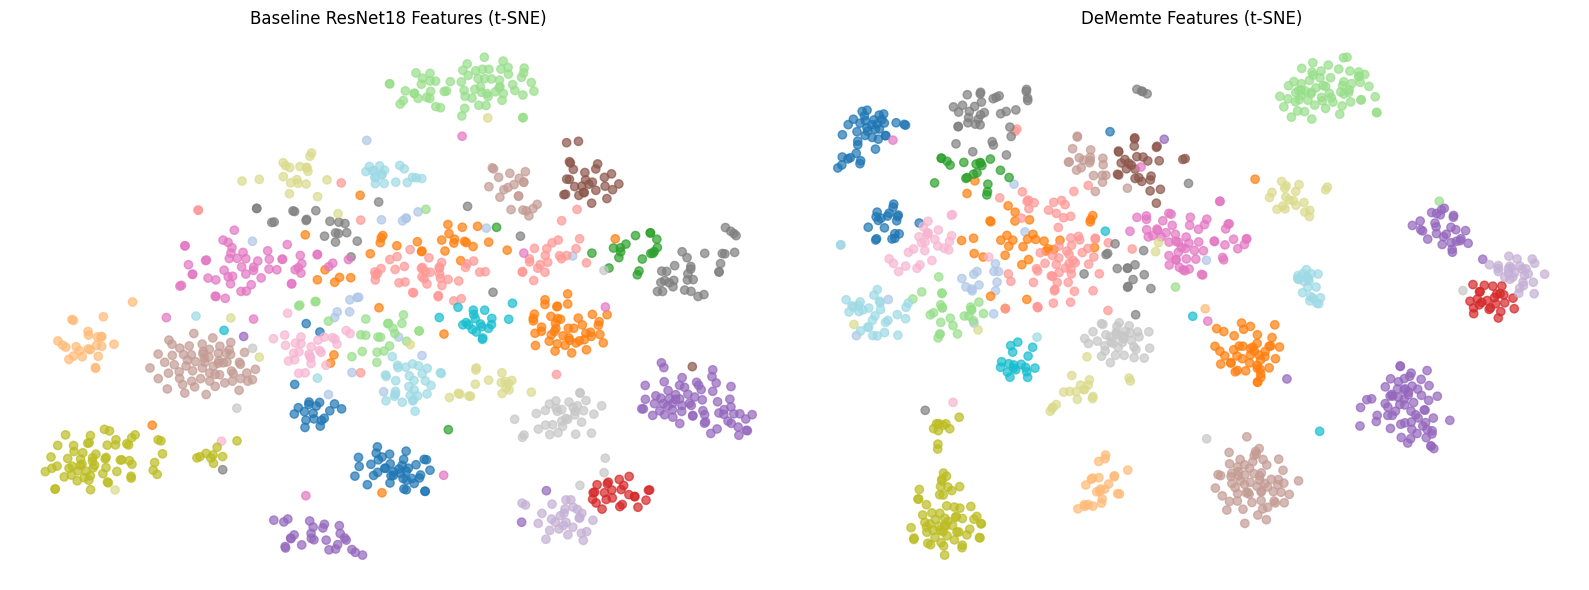

In [8]:
print("Extracting features for t-SNE (Flowers102)...")
X_tsne_base, y_tsne_base = extract_features(baseline_model, testloader_flowers, is_dememte=False, max_samples=1000)
X_tsne_dem, y_tsne_dem = extract_features(dememte_model, testloader_flowers, is_dememte=True, max_samples=1000)

print("Computing t-SNE...")
tsne = TSNE(n_components=2, random_state=42)
X_tsne_base_2d = tsne.fit_transform(X_tsne_base)
X_tsne_dem_2d = tsne.fit_transform(X_tsne_dem)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = ax1.scatter(X_tsne_base_2d[:, 0], X_tsne_base_2d[:, 1], c=y_tsne_base, cmap='tab20', alpha=0.7)
ax1.set_title("Baseline ResNet18 Features (t-SNE)")
ax1.axis('off')

scatter2 = ax2.scatter(X_tsne_dem_2d[:, 0], X_tsne_dem_2d[:, 1], c=y_tsne_dem, cmap='tab20', alpha=0.7)
ax2.set_title("DeMemte Features (t-SNE)")
ax2.axis('off')

plt.tight_layout()
plt.show()